# Diwali Sales Analysis — Exploratory Data Analysis

## Objective:
Analyze Diwali sales transaction data to understand customer buying behavior — across gender, age, marital status, occupation, and location — and identify which product categories drive the most sales. The goal is to turn raw transaction data into insights that can guide marketing targeting and inventory planning.

## Dataset:
`Diwali Sales Data.csv` — customer-level transaction records (Age, Gender, Marital Status, State, Occupation, Product Category, Product ID, Orders, Amount).

## Tools:
Python, Pandas, NumPy, Matplotlib, Seaborn

## 1. Import Libraries

In [4]:
# import python libraries

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt # visualizing data
%matplotlib inline
import seaborn as sns

## 2. Load the Dataset

In [6]:
# import csv file
# encoding='unicode_escape' handles special characters that plain utf-8 can't decode
df = pd.read_csv('Diwali Sales Data.csv', encoding= 'unicode_escape')

In [7]:
# Quick look at the shape (rows, columns) of the raw data
df.shape

(11251, 15)

In [8]:
# Preview the first few rows to understand the structure of the data
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [9]:
# Get column names, data types, and non-null counts in one view
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


### Insight:
A quick look at `.info()` shows which columns have missing values and whether numeric columns (like `Amount`) are being read with the correct data type. This tells us what needs to be cleaned before analysis.

## 3. Data Cleaning

In [12]:
# Drop columns that aren't useful for this analysis:
# - 'Status' and 'unnamed1' are blank/irrelevant columns carried over from the raw export
df.drop(['Status', 'unnamed1'], axis=1, inplace=True)

In [13]:
# Check how many missing values exist in each column
pd.isnull(df).sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [14]:
# drop null values
df.dropna(inplace=True)

In [15]:
# Confirm the new shape after cleaning
df.shape

(11239, 13)

In [16]:
# 'Amount' should be numeric for aggregation, but may be read as float/object.
# Convert it to integer type for cleaner grouping and plotting.
df['Amount'] = df['Amount'].astype('int')

In [17]:
df['Amount'].dtypes

dtype('int32')

In [18]:
# Rename a column for clarity/consistency if needed (example — adjust as required)
df.rename(columns={'Marital_Status': 'Marital_Status'}, inplace=True)

In [19]:
# Confirm all column names after cleaning
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

### Insight: 
After cleaning, the dataset is free of nulls and irrelevant columns, and `Amount` is now a proper integer column — ready for grouping, aggregation, and plotting.

In [21]:
# describe() method returns description of the data in the DataFrame (i.e. count, mean, std, etc)
df.describe()

,User_ID,Age,Marital_Status,Orders,Amount
count,1.123900e+04,11239.000000,11239.000000,11239.000000,11239.000000
mean,1.003004e+06,35.410357,0.420055,2.489634,9453.610553
std,1.716039e+03,12.753866,0.493589,1.114967,5222.355168
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,0.000000,2.000000,5443.000000
50%,1.003064e+06,33.000000,0.000000,2.000000,8109.000000
75%,1.004426e+06,43.000000,1.000000,3.000000,12675.000000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


In [22]:
# Focused summary on the columns most relevant to this analysis
df[['Age', 'Orders', 'Amount']].describe()

,Age,Orders,Amount
count,11239.000000,11239.000000,11239.000000
mean,35.410357,2.489634,9453.610553
std,12.753866,1.114967,5222.355168
min,12.000000,1.000000,188.000000
25%,27.000000,2.000000,5443.000000
50%,33.000000,2.000000,8109.000000
75%,43.000000,3.000000,12675.000000
max,92.000000,4.000000,23952.000000


### Insight: 
This gives a sense of scale — the typical order size, the age range of customers, and the spread of transaction amounts — before diving into segment-level analysis.

## 4. Exploratory Data Analysis

### 4.1 Gender

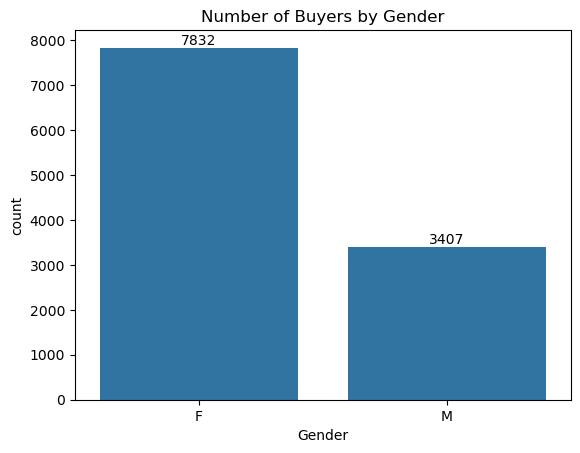

In [26]:
# Count of buyers by gender

ax = sns.countplot(x = 'Gender',data = df)

for bars in ax.containers:
    ax.bar_label(bars)
plt.title('Number of Buyers by Gender')
plt.show()

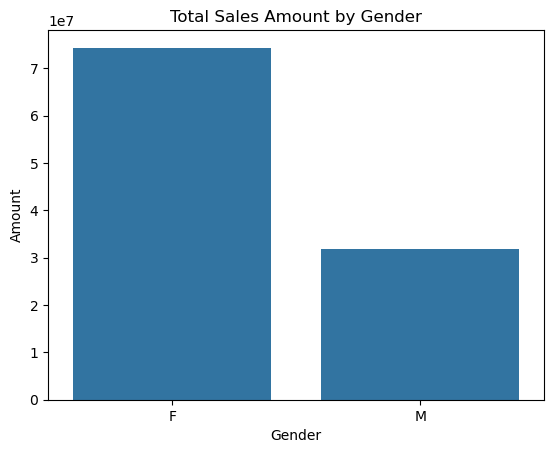

In [27]:
# Total sales amount by gender

sales_gen = df.groupby(['Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

sns.barplot(x = 'Gender',y= 'Amount' ,data = sales_gen)
plt.title('Total Sales Amount by Gender')
plt.show()

### Insight:
Female customers outnumber male customers, and also account for a higher total sales amount — indicating stronger purchasing power among women in this dataset.

### 4.2 Age

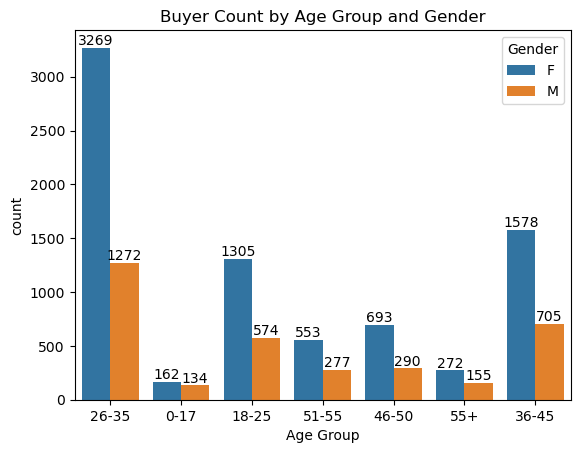

In [30]:
# Buyer count by Age Group, split further by Gender
ax = sns.countplot(data = df, x = 'Age Group', hue = 'Gender')

for bars in ax.containers:
    ax.bar_label(bars)
plt.title('Buyer Count by Age Group and Gender')
plt.show()

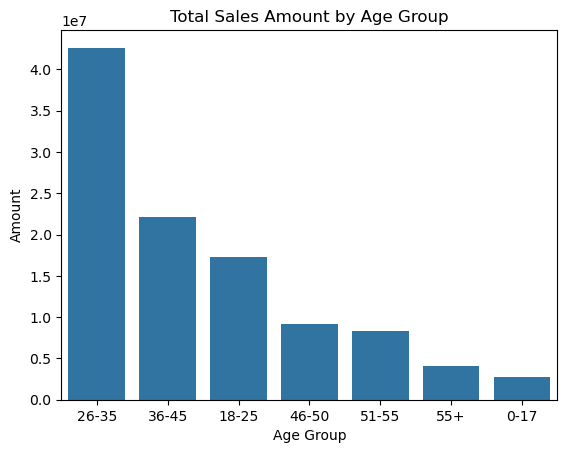

In [31]:
# Total sales amount by Age Group
sales_age = df.groupby(['Age Group'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

sns.barplot(x = 'Age Group',y= 'Amount' ,data = sales_age)
plt.title('Total Sales Amount by Age Group')
plt.show()

### Insight:
The 26–35 age group is the most active and highest-spending segment, and this pattern is especially strong among female buyers.

### 4.3 State

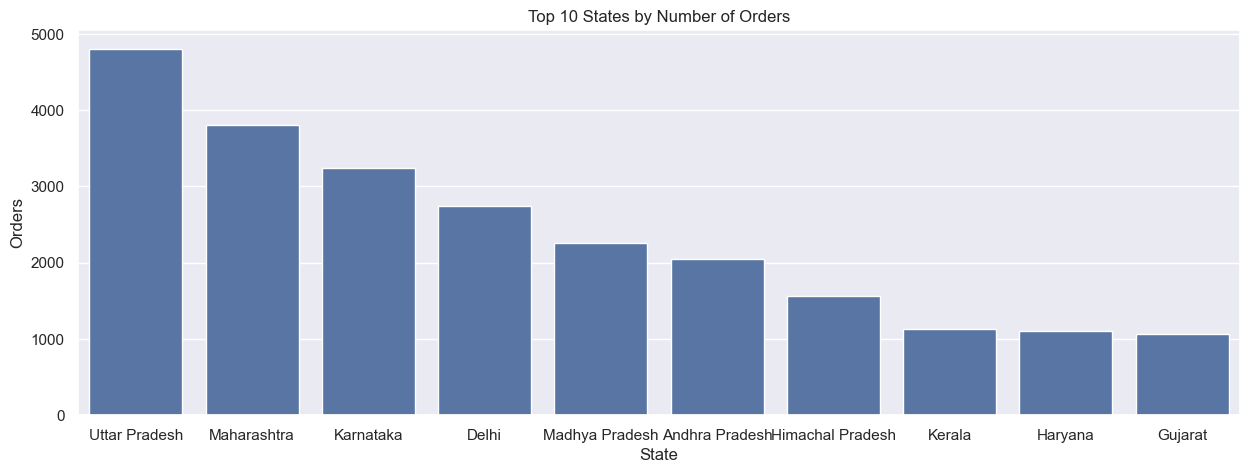

In [34]:
# Top 10 states by total number of orders

sales_state = df.groupby(['State'], as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(10)

sns.set(rc={'figure.figsize':(15,5)})
sns.barplot(data = sales_state, x = 'State',y= 'Orders')
plt.title('Top 10 States by Number of Orders')
plt.show()

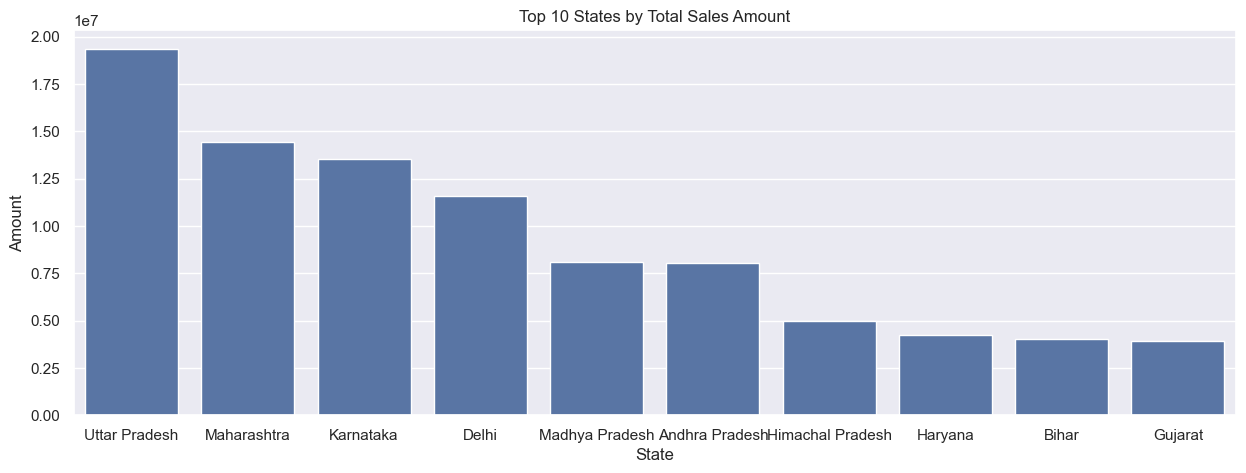

In [35]:
# Top 10 states by total sales amount

sales_state = df.groupby(['State'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(10)

sns.set(rc={'figure.figsize':(15,5)})
sns.barplot(data = sales_state, x = 'State',y= 'Amount')
plt.title('Top 10 States by Total Sales Amount')
plt.show()

### Insight:
Uttar Pradesh, Maharashtra, and Karnataka lead in both order volume and total sales, making them priority states for stocking and regional marketing.


### 4.4 Marital Status

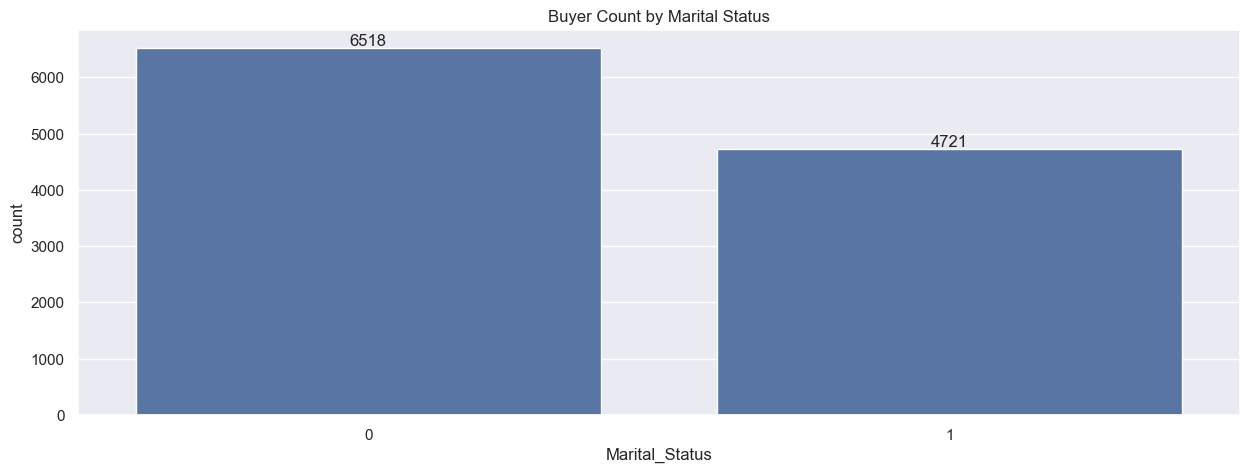

In [38]:
# Count of buyers by marital status
ax = sns.countplot(data = df, x = 'Marital_Status')

sns.set(rc={'figure.figsize':(7,5)})
for bars in ax.containers:
    ax.bar_label(bars)
plt.title('Buyer Count by Marital Status')
plt.show()

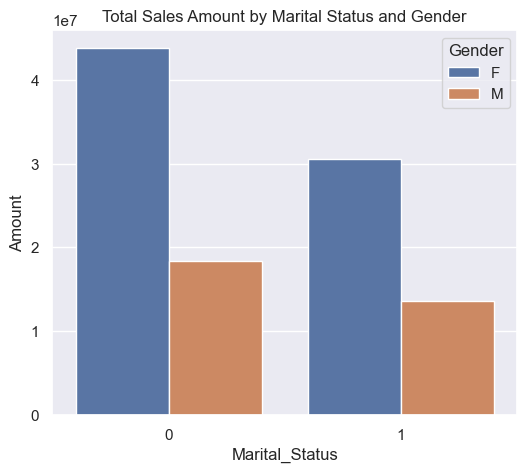

In [39]:
# Total sales amount by marital status, split by gender
sales_state = df.groupby(['Marital_Status', 'Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

sns.set(rc={'figure.figsize':(6,5)})
sns.barplot(data = sales_state, x = 'Marital_Status',y= 'Amount', hue='Gender')
plt.title('Total Sales Amount by Marital Status and Gender')
plt.show()

### Insight: 
Married customers — particularly married women — show higher purchasing power than unmarried customers, reinforcing the "married women 26–35" core segment.

### 4.5 Occupation

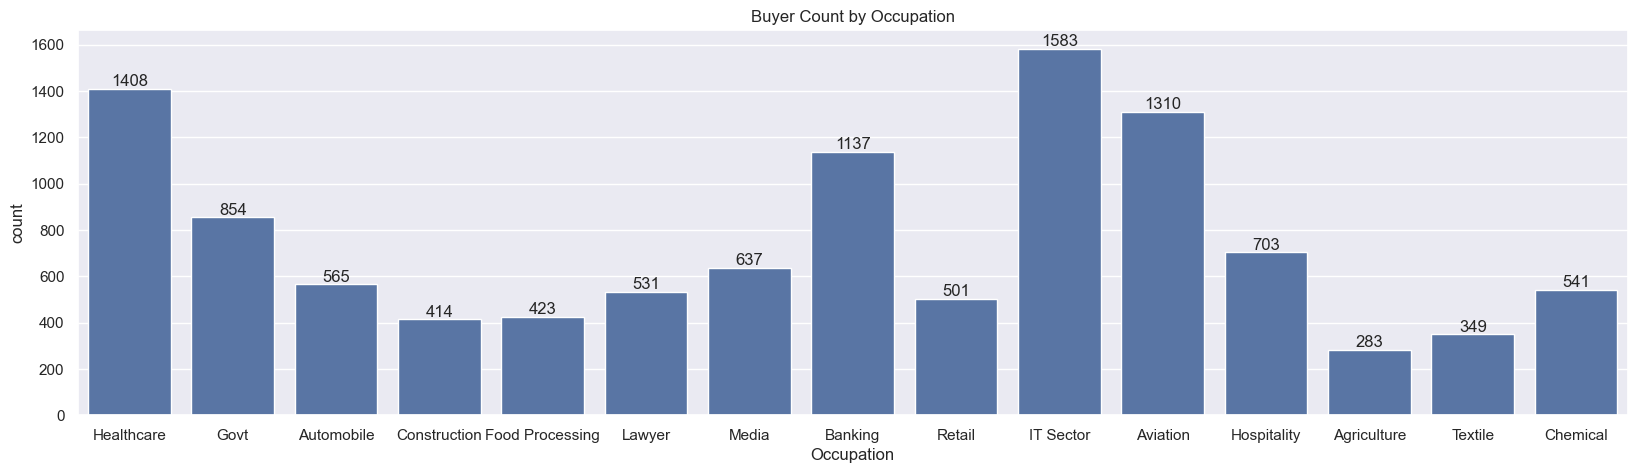

In [42]:
# Count of buyers by occupation
sns.set(rc={'figure.figsize':(20,5)})
ax = sns.countplot(data = df, x = 'Occupation')

for bars in ax.containers:
    ax.bar_label(bars)
plt.title('Buyer Count by Occupation')
plt.show()

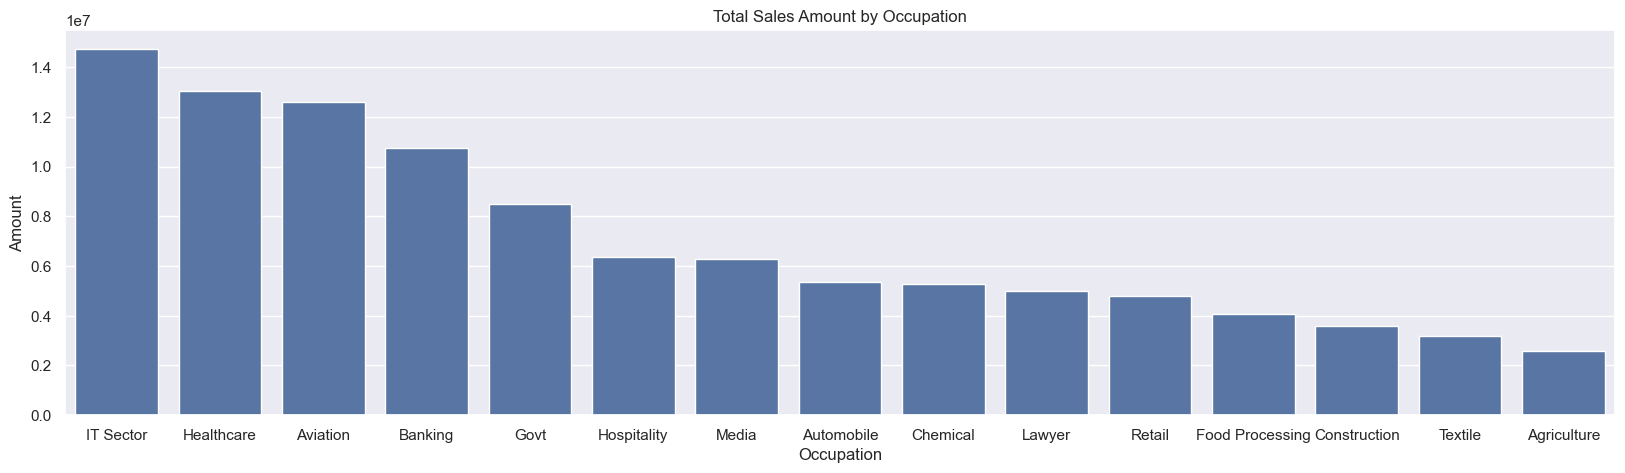

In [43]:
# Total sales amount by occupation
sales_state = df.groupby(['Occupation'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data = sales_state, x = 'Occupation',y= 'Amount')
plt.title('Total Sales Amount by Occupation')
plt.show()

### Insight:
Buyers working in IT, Healthcare, and Aviation contribute the most to total sales — useful for occupation-targeted marketing or partnership offers (e.g., corporate discounts).

### 4.6 Product Category

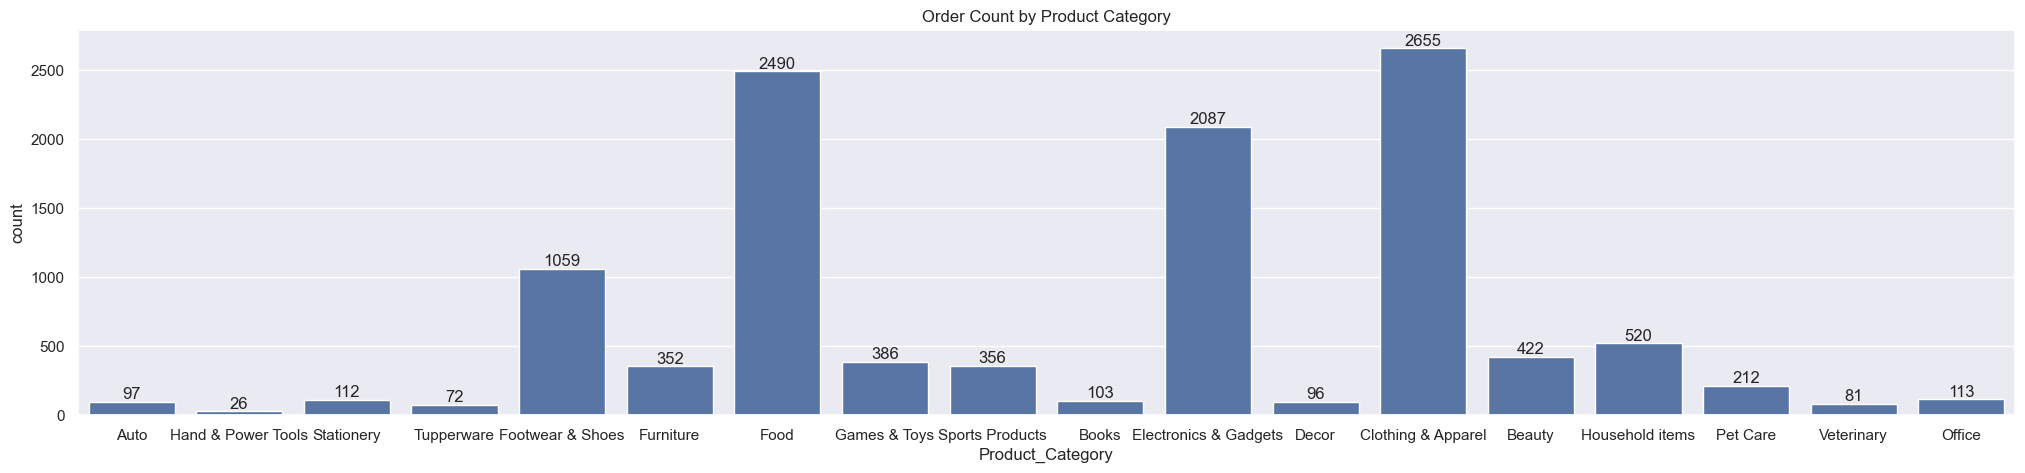

In [46]:
# Count of orders by product category
sns.set(rc={'figure.figsize':(25,5)})
ax = sns.countplot(data = df, x = 'Product_Category')

for bars in ax.containers:
    ax.bar_label(bars)
plt.title('Order Count by Product Category')
plt.show()

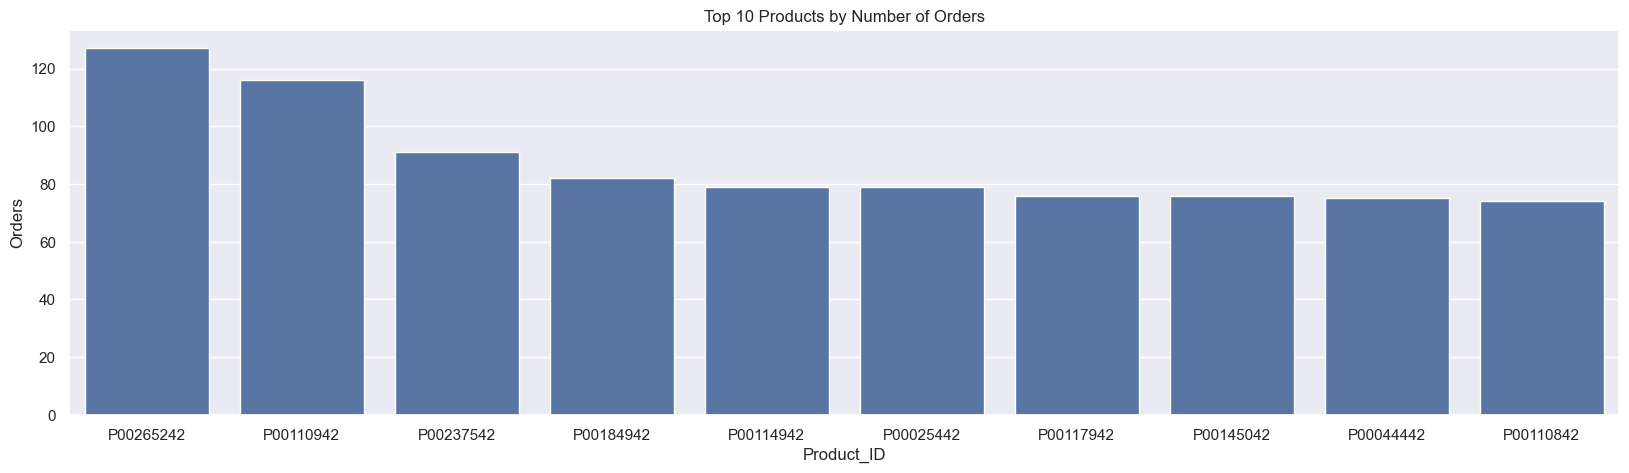

In [47]:
# Top 10 individual products by number of orders
sales_state = df.groupby(['Product_ID'], as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(10)

sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data = sales_state, x = 'Product_ID',y= 'Orders')
plt.title('Top 10 Products by Number of Orders')
plt.show()

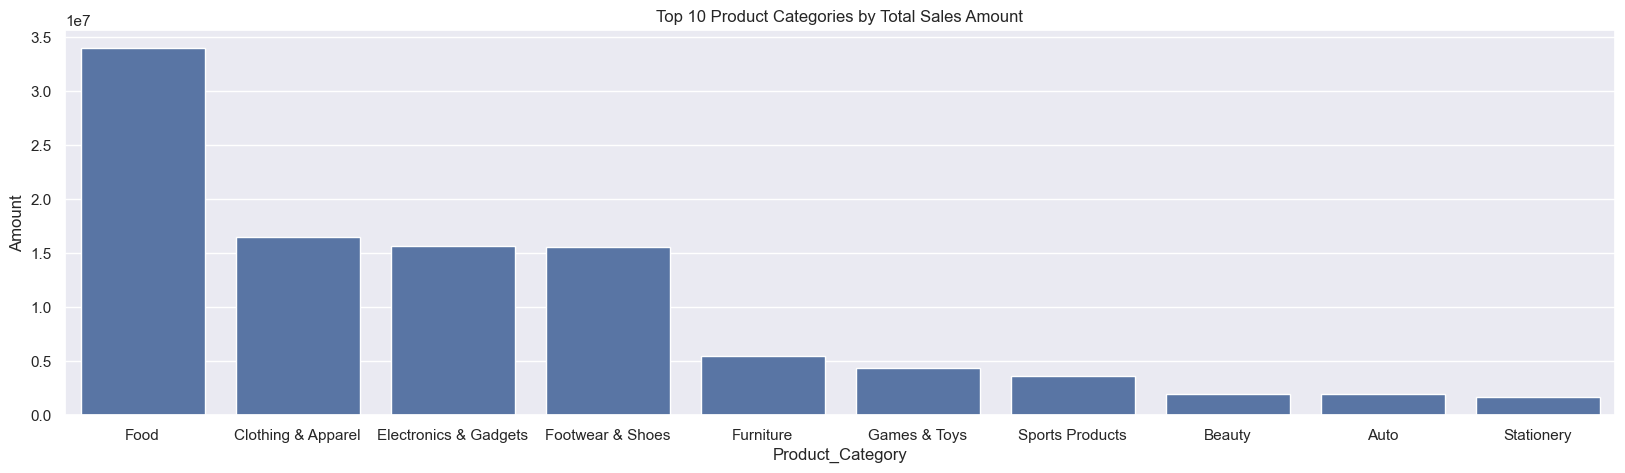

In [48]:
# Top 10 product categories by total sales amount
sales_state = df.groupby(['Product_Category'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(10)

sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data = sales_state, x = 'Product_Category',y= 'Amount')
plt.title('Top 10 Product Categories by Total Sales Amount')
plt.show()

### Insight: 
Food, Clothing, and Electronics are the top-selling categories by both order count and revenue — these should be prioritized for festive-season stocking.

##  Additional Analysis — Correlation Between Numeric Features

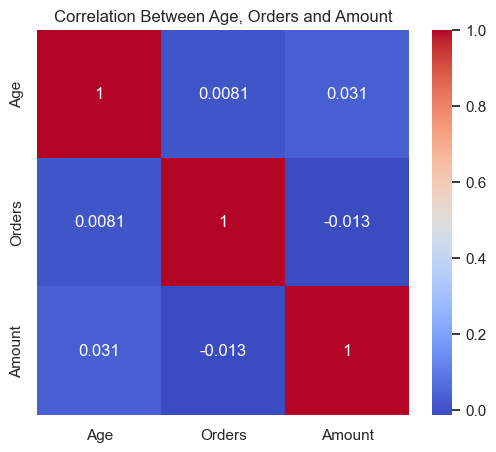

In [51]:
# Correlation heatmap between Age, Orders, and Amount
plt.figure(figsize=(6, 5))
corr = df[['Age', 'Orders', 'Amount']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Between Age, Orders and Amount')
plt.show()

### Insight:
Age, Orders, and Amount show almost no correlation with each other — meaning more orders doesn't mean higher spend, and age doesn't predict purchase behavior. Demographic factors like Gender, State, and Occupation explain sales patterns better than these numeric variables.

## 5. Conclusion

Based on the analysis above:

- **Who buys the most:** Married women, aged 26–35, from Uttar Pradesh, Maharashtra, and Karnataka, working in IT, Healthcare, or Aviation.
- **What they buy:** Primarily Food, Clothing, and Electronics.
- **Why it matters:** This customer profile can guide targeted marketing campaigns and help plan inventory ahead of festive demand, focusing on the top-performing states and categories.



### Note:
This project was built and coded independently by me, based on the concepts and workflow taught in a public tutorial on Diwali sales analysis, as a practice project to strengthen my exploratory data analysis skills in Python.

Thank you!